In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import numpy as np
from typing import Optional, Sequence
from pandas.api.types import is_datetime64_any_dtype


In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
pd.set_option("display.max_colwidth", None) 
pd.set_option('display.max_rows', None)
pd.set_option("display.float_format", "{:.2f}".format)

In [3]:
metric_columns = [
    "model",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
]

metrics_df = pd.DataFrame(columns=metric_columns)


def add_model_metrics(metrics_df: pd.DataFrame, metrics: dict) -> pd.DataFrame:
    metrics_row = pd.DataFrame([metrics], columns=metric_columns)
    metrics_df = metrics_df.loc[metrics_df["model"] != metrics["model"]].copy()
    return pd.concat([metrics_df, metrics_row], ignore_index=True)

metrics_df

,model,accuracy,precision,recall,f1,roc_auc


# 1. Data import

In [4]:
df = pd.read_csv('dataset_latam.csv')

In [5]:
df = df.drop(columns=['Unnamed: 0'])

# 2. Data understanding

In [6]:
df.describe()

,speed_internet,had_sessions_before_quiz,days_since_last_ga_session_asof,quiz_completion_time_seconds,questions_count,amocrm_id,stud_age_amo,age,impressions,link_clicks,spend_usd,visited_tc_7d_target,hour_first_booking_timeslot,gap_lead_to_mk_hours,days_to_mk
count,5557.00,5458.00,714.00,5690.00,5690.00,5690.00,5690.00,5452.00,5316.00,5315.00,5316.00,5690.00,5690.00,5690.00,5690.00
mean,3.40,0.13,18.27,767.71,12.52,39575498.01,10.46,10.43,213269.91,1594.57,266.56,0.23,16.17,46.37,1.77
std,1.52,0.34,22.64,16582.11,3.24,255456.61,2.55,2.57,172362.64,923.33,107.31,0.42,7.36,359.73,14.99
min,0.00,0.00,1.00,0.00,1.00,35539150.00,5.00,5.00,0.00,0.00,0.00,0.00,0.00,-14003.00,-583.00
25%,2.52,0.00,2.00,80.96,13.00,39401161.00,9.00,8.00,99061.00,1003.00,200.23,0.00,16.00,18.00,1.00
50%,3.34,0.00,8.50,107.51,13.00,39598975.00,10.00,10.00,163296.00,1426.00,255.96,0.00,19.00,40.00,2.00
75%,4.25,0.00,24.00,151.19,13.00,39750287.50,12.00,12.00,274764.00,2159.00,335.23,0.00,21.00,78.00,3.00
max,21.92,1.00,92.00,688280.14,53.00,39931358.00,17.00,17.00,910885.00,4761.00,655.52,1.00,23.00,1833.00,76.00


In [7]:
df.dtypes

first_booking_timeslot              object
last_booking_timeslot               object
speed_internet                     float64
had_sessions_before_quiz           float64
days_since_last_ga_session_asof    float64
time_started                        object
time_end                            object
quiz_completion_time_seconds       float64
questions_count                      int64
os_device                           object
device_type                         object
brand_device                        object
country                             object
amocrm_id                            int64
source                              object
utm_marketing                       object
last_booking_status                 object
stud_age_amo                         int64
marketing_course_global             object
device_type_ui                      object
utm_referrer                        object
monthly_budget                      object
extracurricular_spend               object
respondent 

Duplicates

In [8]:
n_dup = df.duplicated().sum()
print(f"Duplicate rows: {n_dup:,}  ({n_dup / len(df):.2%})")

Duplicate rows: 0  (0.00%)


Type conversions

In [9]:
date_cols = ["first_booking_timeslot", "last_booking_timeslot", "time_started",
             "time_end"]

df[date_cols] = df[date_cols].apply(
    pd.to_datetime,
    errors="coerce"
)

Translate day-of-week columns to English

In [10]:
day_of_week_map = {
    "понедельник": "Monday",
    "вторник": "Tuesday",
    "среда": "Wednesday",
    "четверг": "Thursday",
    "пятница": "Friday",
    "суббота": "Saturday",
    "воскресенье": "Sunday",
}

day_of_week_cols = ["day_of_week_tc", "day_of_week_quiz_start"]
df[day_of_week_cols] = df[day_of_week_cols].replace(day_of_week_map)

df[day_of_week_cols].head()

,day_of_week_tc,day_of_week_quiz_start
0,Thursday,Thursday
1,Tuesday,Sunday
2,Monday,Friday
3,Wednesday,Tuesday
4,Tuesday,Saturday


In [11]:
cat_cols = [
    "os_device",
    "device_type",
    "brand_device",
    "country",
    "source",
    "utm_marketing",
    "last_booking_status",
    "marketing_course_global",
    "device_type_ui",
    "utm_referrer",
    "monthly_budget",
    "extracurricular_spend",
    "respondent",
    "took_online_classes_before",
    "reaction_to_trial_class",
    "gender",
    "decision_responsibility",
    "free_time",
    "internet_stability",
    "would_pay_if_useful",
    "has_computer",
    "utm_content",
    "utm_campaign",
    "utm_medium",
    "utm_source",
    "region",
    "campaign_event_empiric",
    "ad_back_empiric",
    "ad_group_product",
    "ad_hero_dynamic_empiric",
    "ad_product_empiric",
    "creative_call_to_action_type",
    "campaign_offer_empiric",
    "campaign_bid_strategy_empiric",
    "course_global",
    "format",
    "creative_concept",
    "landing_id",
    "product_offer_empiric",
    "creative_uvp",
    "day_of_week_tc",
    "day_of_week_quiz_start",
]
df[cat_cols] = df[cat_cols].astype("category")

In [12]:
df["visited_tc_7d_target"] = df["visited_tc_7d_target"].astype(int)

Missing values

In [13]:
df.isna().mean().sort_values(ascending=False)

creative_call_to_action_type      1.00
ad_back_empiric                   0.96
ad_hero_dynamic_empiric           0.96
creative_concept                  0.88
ad_group_product                  0.88
days_since_last_ga_session_asof   0.87
creative_uvp                      0.87
ad_product_empiric                0.87
landing_id                        0.87
format                            0.87
utm_content                       0.84
respondent                        0.07
monthly_budget                    0.07
link_clicks                       0.07
impressions                       0.07
spend_usd                         0.07
would_pay_if_useful               0.07
gender                            0.06
extracurricular_spend             0.06
has_computer                      0.06
internet_stability                0.06
free_time                         0.06
decision_responsibility           0.06
took_online_classes_before        0.06
reaction_to_trial_class           0.06
campaign_offer_empiric   

Cardinality check

In [14]:
df[cat_cols].nunique().sort_values(ascending=False)

utm_referrer                     5277
utm_marketing                     196
utm_content                       188
utm_campaign                      120
os_device                          83
country                            31
ad_hero_dynamic_empiric            24
landing_id                         18
creative_concept                   18
utm_medium                         17
brand_device                       15
product_offer_empiric              14
creative_uvp                       13
utm_source                         12
source                             12
ad_product_empiric                  9
ad_back_empiric                     9
region                              8
day_of_week_quiz_start              7
day_of_week_tc                      7
campaign_bid_strategy_empiric       6
ad_group_product                    6
format                              5
reaction_to_trial_class             4
course_global                       4
free_time                           4
marketing_co

Target distribution (total visited tc vs not-visited)

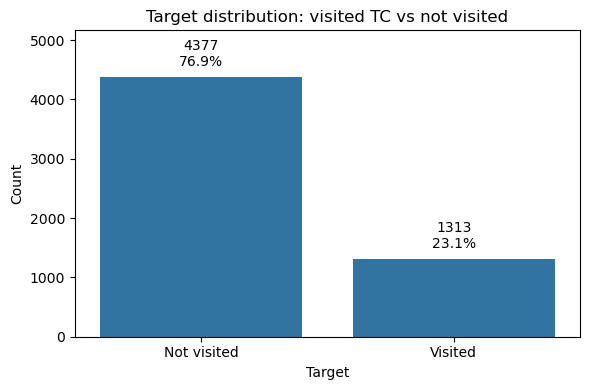

In [15]:
target_col = "visited_tc_7d_target"

target_counts = df[target_col].value_counts().sort_index()
target_share = df[target_col].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    x=target_counts.index.astype(str),
    y=target_counts.values
)

max_count = target_counts.max()
ax.set_ylim(0, max_count * 1.18)

for i, count in enumerate(target_counts.values):
    pct = target_share.iloc[i]
    ax.text(
        i,
        count + max_count * 0.03,
        f"{count}\n{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Target distribution: visited TC vs not visited")
plt.xlabel("Target")
plt.ylabel("Count")
plt.xticks(
    ticks=[0, 1],
    labels=["Not visited", "Visited"]
)

plt.tight_layout()
plt.show()

## Categorical feature histograms

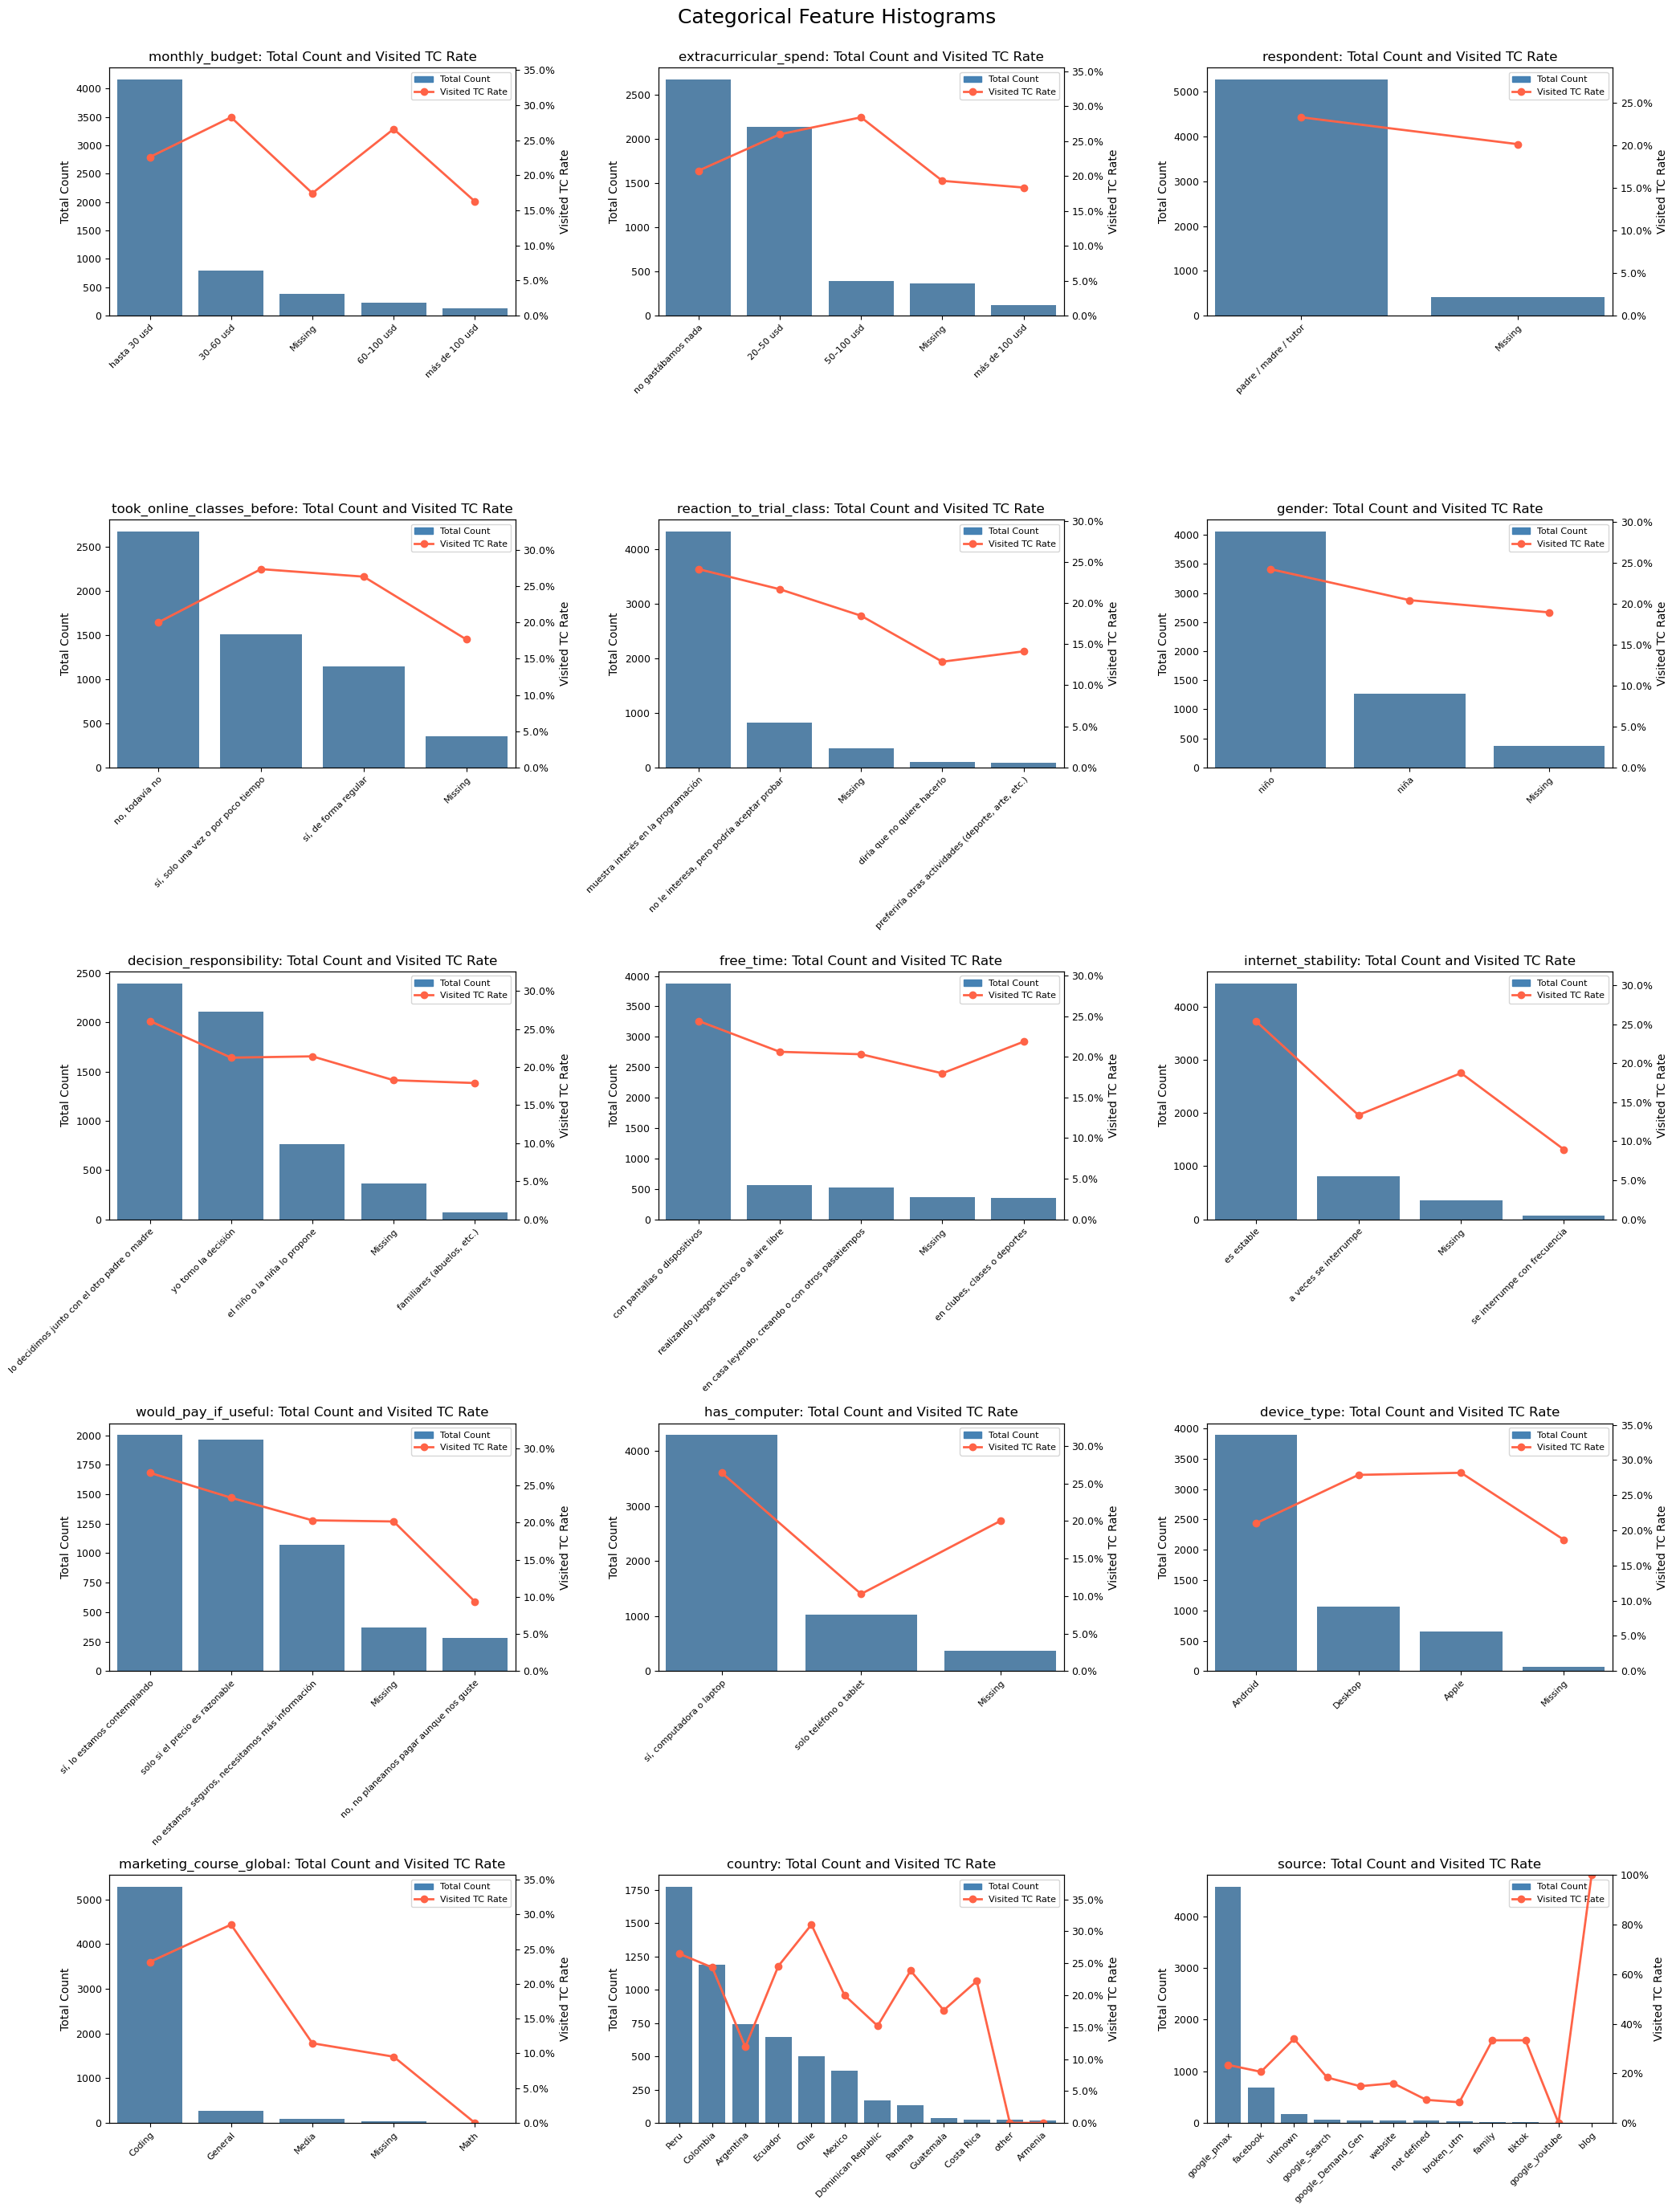

In [16]:
target_col = "visited_tc_7d_target"

cat_cols = [
    "monthly_budget",
    "extracurricular_spend",
    "respondent",
    "took_online_classes_before",
    "reaction_to_trial_class",
    "gender",
    "decision_responsibility",
    "free_time",
    "internet_stability",
    "would_pay_if_useful",
    "has_computer",
    "device_type",
    "marketing_course_global",
    "country",
    "source",
]

cat_cols = [col for col in cat_cols if col in df.columns]

top_n = 12
ncols = 3
max_rows = 5
cat_cols = cat_cols[: ncols * max_rows]
nrows = (len(cat_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5.5 * nrows), squeeze=False)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax1 = axes[i]
    tmp = df[[col, target_col]].copy()
    tmp[col] = tmp[col].astype("object").fillna("Missing")

    top_categories = tmp[col].value_counts().head(top_n).index
    tmp = tmp[tmp[col].isin(top_categories)]

    plot_df = (
        tmp.groupby(col, observed=False)
        .agg(
            total_count=(target_col, "size"),
            visited_rate=(target_col, "mean")
        )
        .reset_index()
        .sort_values("total_count", ascending=False)
    )

    plot_df[col] = plot_df[col].astype(str)

    sns.barplot(
        data=plot_df,
        x=col,
        y="total_count",
        ax=ax1,
        color="steelblue"
    )

    ax1.set_title(f"{col}: Total Count and Visited TC Rate", fontsize=12)
    ax1.set_xlabel("")
    ax1.set_ylabel("Total Count", color="black")
    ax1.tick_params(axis="y", labelcolor="black", labelsize=9)
    ax1.tick_params(axis="x", labelsize=8, rotation=45)

    for label in ax1.get_xticklabels():
        label.set_ha("right")
        label.set_rotation_mode("anchor")

    ax2 = ax1.twinx()

    ax2.plot(
        range(len(plot_df)),
        plot_df["visited_rate"],
        color="tomato",
        marker="o",
        linewidth=2,
        label="Visited TC Rate"
    )

    ax2.set_ylabel("Visited TC Rate", color="black")
    ax2.tick_params(axis="y", labelcolor="black", labelsize=9)
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

    ax1.margins(x=0.02)
    ax2.set_ylim(0, min(1, plot_df["visited_rate"].max() * 1.25))

    bar_patch = plt.Rectangle((0, 0), 1, 1, color="steelblue")
    line_patch = plt.Line2D(
        [0],
        [0],
        color="tomato",
        marker="o",
        linewidth=2
    )

    ax1.legend(
        [bar_patch, line_patch],
        ["Total Count", "Visited TC Rate"],
        loc="upper right",
        fontsize=8
    )

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Categorical Feature Histograms", fontsize=18, y=1.0)
fig.tight_layout()
fig.savefig("categorical_feature_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

## Target share by categorical values

In [17]:
target_col = "visited_tc_7d_target"

def target_share_by_category(df, col, target_col=target_col, top_n=None, min_count=0):
    tmp = df[[col, target_col]].copy()
    tmp[col] = tmp[col].astype("object").fillna("Missing")

    summary = (
        tmp.groupby(col, observed=False)
        .agg(
            total_count=(target_col, "size"),
            target_count=(target_col, "sum"),
            visited_rate=(target_col, "mean"),
        )
        .reset_index()
        .sort_values("total_count", ascending=False)
    )

    summary["observation_share_pct"] = summary["total_count"].div(len(tmp)).mul(100)
    summary["visited_rate_pct"] = summary["visited_rate"].mul(100)
    summary = summary.drop(columns="visited_rate")
    summary[col] = summary[col].astype(str)
    summary = summary.rename(columns={col: "category"})
    summary.insert(0, "feature", col)

    if min_count:
        summary = summary[summary["total_count"] >= min_count]
    if top_n is not None:
        summary = summary.head(top_n)

    return summary[
        ["feature", "category", "total_count", "observation_share_pct", "target_count", "visited_rate_pct"]
    ].round({"observation_share_pct": 2, "visited_rate_pct": 2})


geo_source_cols = ["country", "source"]
readiness_intent_cols = [
    "internet_stability",
    "has_computer",
    "would_pay_if_useful",
    "monthly_budget",
    "extracurricular_spend",
]

geo_source_target_summary = pd.concat(
    [target_share_by_category(df, col, top_n=12) for col in geo_source_cols if col in df.columns],
    ignore_index=True,
)

readiness_intent_target_summary = pd.concat(
    [target_share_by_category(df, col) for col in readiness_intent_cols if col in df.columns],
    ignore_index=True,
)

display(geo_source_target_summary)
display(readiness_intent_target_summary)

,feature,category,total_count,observation_share_pct,target_count,visited_rate_pct
0,country,Peru,1773,31.16,470,26.51
1,country,Colombia,1191,20.93,290,24.35
2,country,Argentina,740,13.01,88,11.89
3,country,Ecuador,647,11.37,159,24.57
4,country,Chile,499,8.77,155,31.06
5,country,Mexico,395,6.94,79,20.00
6,country,Dominican Republic,171,3.01,26,15.20
7,country,Panama,130,2.28,31,23.85
8,country,Guatemala,34,0.60,6,17.65
9,country,Costa Rica,27,0.47,6,22.22


,feature,category,total_count,observation_share_pct,target_count,visited_rate_pct
0,internet_stability,es estable,4451,78.22,1131,25.41
1,internet_stability,a veces se interrumpe,809,14.22,108,13.35
2,internet_stability,Missing,363,6.38,68,18.73
3,internet_stability,se interrumpe con frecuencia,67,1.18,6,8.96
4,has_computer,"sí, computadora o laptop",4293,75.45,1134,26.42
5,has_computer,solo teléfono o tablet,1032,18.14,106,10.27
6,has_computer,Missing,365,6.41,73,20.00
7,would_pay_if_useful,"sí, lo estamos contemplando",2002,35.18,535,26.72
8,would_pay_if_useful,solo si el precio es razonable,1965,34.53,459,23.36
9,would_pay_if_useful,"no estamos seguros, necesitamos más información",1073,18.86,218,20.32


## Box plot diagrams

In [18]:
def plot_delay_boxplots(df, cols, ncols=2):
    if not cols:
        return

    nrows = (len(cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 6 * nrows), squeeze=False)
    axes = axes.flatten()
    
    for i, col in enumerate(cols):
        sns.boxplot(
            data=df, x="visited_tc_7d_target", y=col, ax=axes[i],
            hue="visited_tc_7d_target", palette=["steelblue", "tomato"],
            showfliers=False,
            flierprops=dict(marker=".", markersize=1, alpha=0.2, linestyle="none"),
            legend=False,
        )
        axes[i].set_title(col, fontsize=17)
        axes[i].set_xlabel("1 = Visited TC  |  0 = Not Visited TC", fontsize=14)
        axes[i].tick_params(labelsize=14)
    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle("Feature Distributions: Visited TC vs Not Visited TC", fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

In [19]:
cat_cols = df.select_dtypes(include=["float64", "int64"]).columns.to_list()

In [20]:
cat_cols

['speed_internet',
 'had_sessions_before_quiz',
 'days_since_last_ga_session_asof',
 'quiz_completion_time_seconds',
 'questions_count',
 'amocrm_id',
 'stud_age_amo',
 'age',
 'impressions',
 'link_clicks',
 'spend_usd',
 'visited_tc_7d_target',
 'hour_first_booking_timeslot',
 'gap_lead_to_mk_hours',
 'days_to_mk']

In [21]:
cat_cols.remove('amocrm_id')
cat_cols.remove('questions_count')
cat_cols.remove('had_sessions_before_quiz')
cat_cols.remove('visited_tc_7d_target')

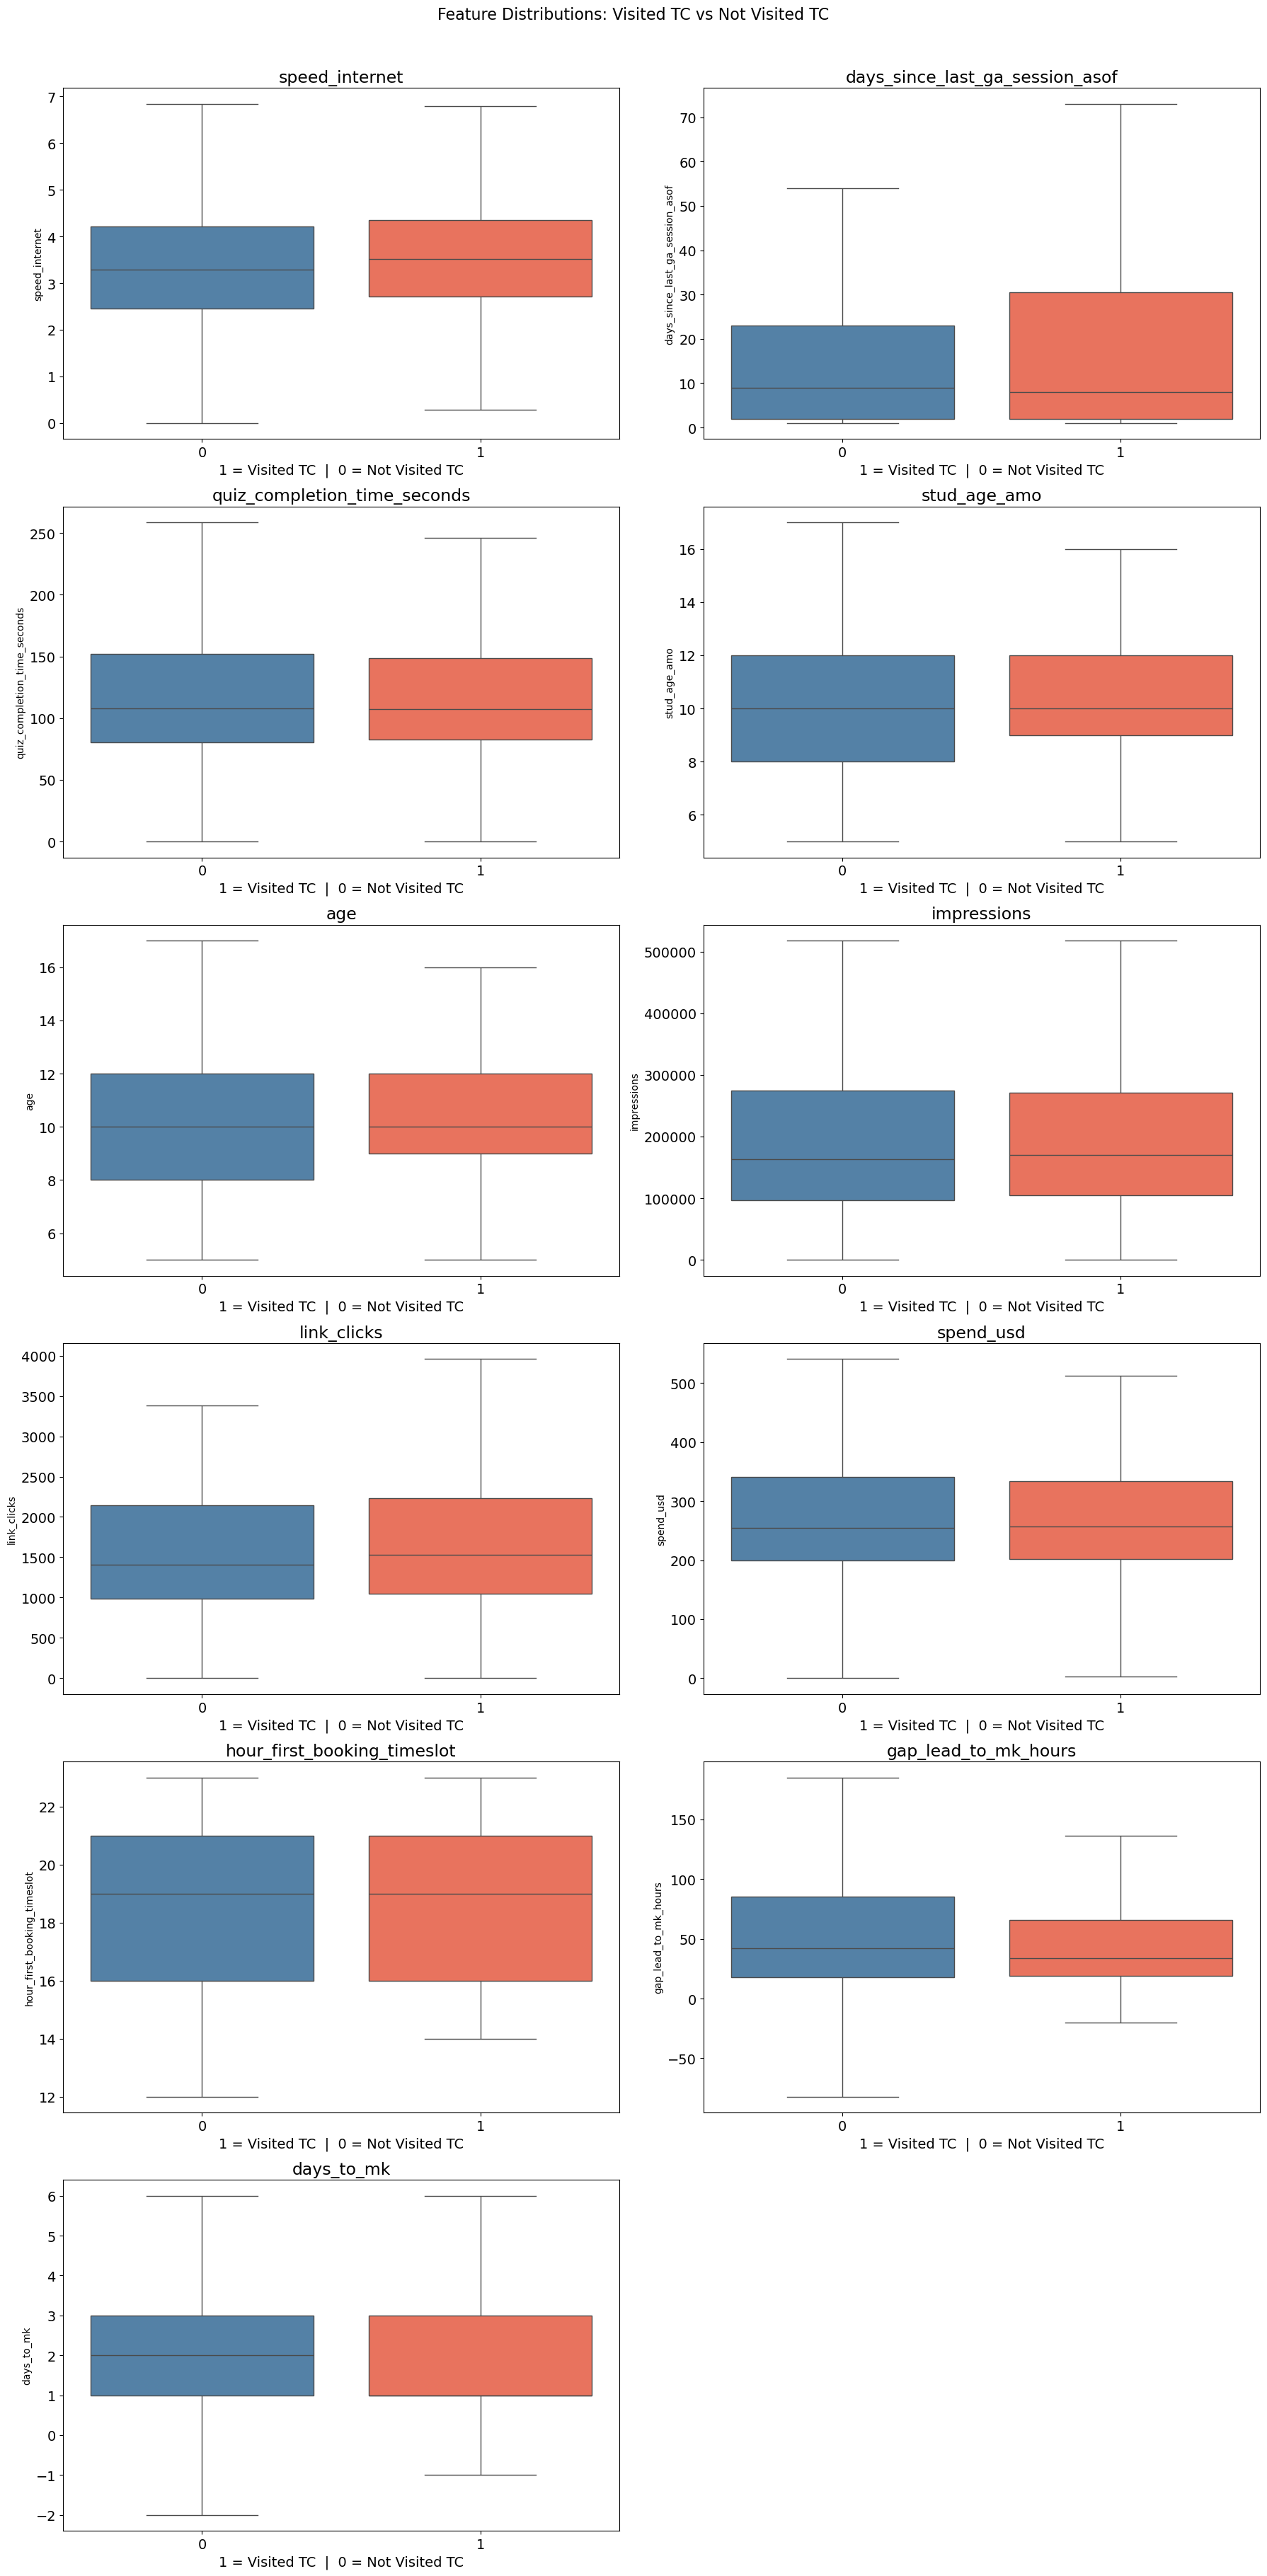

In [22]:
plot_delay_boxplots(df, cat_cols, ncols=2)

## Missing values

In [23]:
missing = df.isnull().sum()
missing_nonzero = missing[missing > 0]

if missing_nonzero.empty:
    print("No NaN values found in any column.")
else:
    print(missing_nonzero)

speed_internet                      133
had_sessions_before_quiz            232
days_since_last_ga_session_asof    4976
os_device                            44
device_type                          75
brand_device                         42
utm_marketing                        44
marketing_course_global              42
device_type_ui                       75
utm_referrer                          4
monthly_budget                      378
extracurricular_spend               368
respondent                          417
took_online_classes_before          357
reaction_to_trial_class             352
age                                 238
gender                              369
decision_responsibility             361
free_time                           362
internet_stability                  363
would_pay_if_useful                 372
has_computer                        365
utm_content                        4799
utm_campaign                         61
utm_medium                           60


In [24]:
missing_percent = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .round(2)
)

missing_percent

creative_call_to_action_type      99.93
ad_back_empiric                   96.17
ad_hero_dynamic_empiric           95.54
creative_concept                  88.26
ad_group_product                  87.70
days_since_last_ga_session_asof   87.45
creative_uvp                      87.05
ad_product_empiric                86.98
landing_id                        86.98
format                            86.98
utm_content                       84.34
respondent                         7.33
monthly_budget                     6.64
link_clicks                        6.59
impressions                        6.57
spend_usd                          6.57
would_pay_if_useful                6.54
gender                             6.49
extracurricular_spend              6.47
has_computer                       6.41
internet_stability                 6.38
free_time                          6.36
decision_responsibility            6.34
took_online_classes_before         6.27
reaction_to_trial_class            6.19


# 3. Data Quality

Missing values by target

In [25]:
missing_by_target = (
    df.groupby(target_col, observed=False)
      .apply(lambda x: x.isna().mean().mul(100))
      .T
      .rename(columns={0: "not_visited_missing_pct", 1: "visited_missing_pct"})
)

for col in ["not_visited_missing_pct", "visited_missing_pct"]:
    if col not in missing_by_target.columns:
        missing_by_target[col] = 0

missing_by_target["abs_diff_pct_points"] = (
    missing_by_target["visited_missing_pct"] - missing_by_target["not_visited_missing_pct"]
).abs()

missing_by_target = missing_by_target.sort_values("abs_diff_pct_points", ascending=False).round(2)
missing_by_target.head(20)

/var/folders/78/8b3g8thx1b99pgrq0245szkr0000gn/T/ipykernel_85376/2588059042.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(target_col, observed=False)


visited_tc_7d_target,not_visited_missing_pct,visited_missing_pct,abs_diff_pct_points
utm_content,83.80,86.14,2.34
monthly_budget,7.13,5.03,2.10
took_online_classes_before,6.72,4.80,1.92
ad_product_empiric,86.54,88.42,1.88
format,86.54,88.42,1.88
landing_id,86.54,88.42,1.88
free_time,6.79,4.95,1.83
creative_uvp,86.63,88.42,1.79
decision_responsibility,6.74,5.03,1.71
creative_concept,87.87,89.57,1.70


Date and time sanity checks

In [26]:
date_quality = pd.DataFrame({
    "missing_count": df[date_cols].isna().sum(),
    "missing_pct": df[date_cols].isna().mean().mul(100).round(2),
    "min": df[date_cols].min(),
    "max": df[date_cols].max(),
})

date_quality

,missing_count,missing_pct,min,max
first_booking_timeslot,0,0.00,2024-04-19 00:00:00.000,2026-03-18 23:00:00.000
last_booking_timeslot,0,0.00,2024-04-19 00:00:00.000,2026-03-18 23:00:00.000
time_started,0,0.00,2025-10-27 12:34:53.763,2026-03-12 15:40:58.603
time_end,0,0.00,2025-10-27 12:35:01.863,2026-03-12 15:43:11.113


In [27]:
time_checks = pd.Series({
    "quiz_end_before_start": (df["time_end"] < df["time_started"]).sum(),
    "last_booking_before_first_booking": (df["last_booking_timeslot"] < df["first_booking_timeslot"]).sum(),
    "trial_class_before_quiz_start": (df["first_booking_timeslot"] < df["time_started"]).sum(),
    "negative_gap_lead_to_mk_hours": (df["gap_lead_to_mk_hours"] < 0).sum(),
    "negative_days_to_mk": (df["days_to_mk"] < 0).sum(),
})

pd.DataFrame({
    "count": time_checks,
    "share_pct": (time_checks / len(df) * 100).round(2),
})

,count,share_pct
quiz_end_before_start,0,0.00
last_booking_before_first_booking,0,0.00
trial_class_before_quiz_start,107,1.88
negative_gap_lead_to_mk_hours,98,1.72
negative_days_to_mk,92,1.62


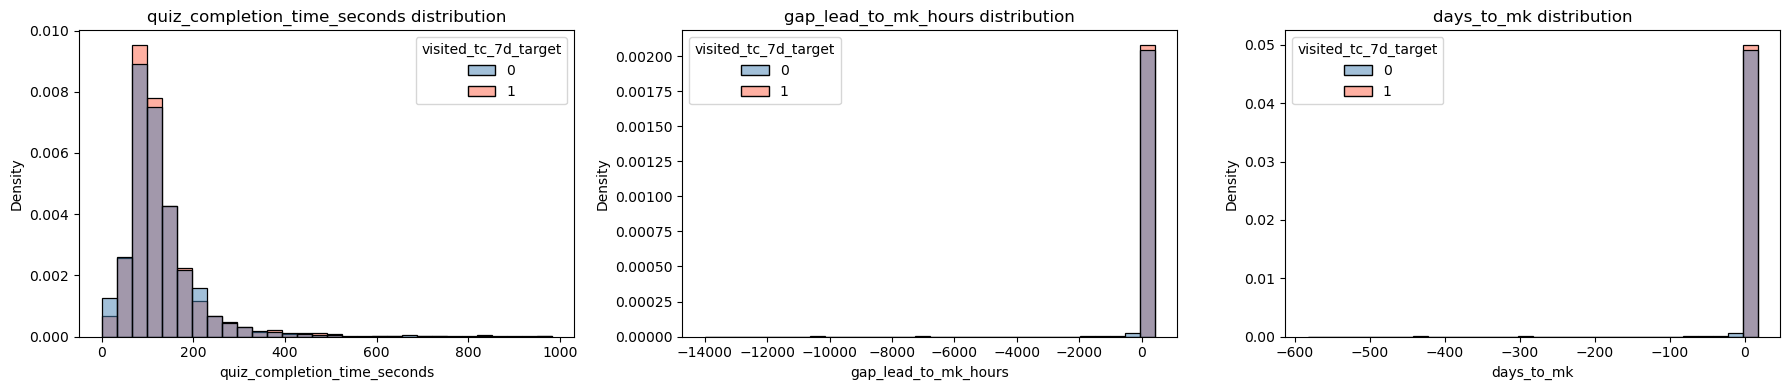

In [28]:
time_plot_cols = ["quiz_completion_time_seconds", "gap_lead_to_mk_hours", "days_to_mk"]
time_plot_cols = [col for col in time_plot_cols if col in df.columns]

fig, axes = plt.subplots(1, len(time_plot_cols), figsize=(6 * len(time_plot_cols), 4), squeeze=False)

for ax, col in zip(axes.flatten(), time_plot_cols):
    upper = df[col].quantile(0.99)
    sns.histplot(
        data=df[df[col].between(df[col].min(), upper)],
        x=col,
        hue=target_col,
        bins=30,
        stat="density",
        common_norm=False,
        palette=["steelblue", "tomato"],
        ax=ax,
    )
    ax.set_title(f"{col} distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

Numeric sanity checks

In [29]:
non_negative_cols = [
    "speed_internet",
    "had_sessions_before_quiz",
    "days_since_last_ga_session_asof",
    "quiz_completion_time_seconds",
    "questions_count",
    "stud_age_amo",
    "age",
    "impressions",
    "link_clicks",
    "spend_usd",
    "hour_first_booking_timeslot",
    "gap_lead_to_mk_hours",
    "days_to_mk",
]
non_negative_cols = [col for col in non_negative_cols if col in df.columns]

sanity_rows = []
for col in non_negative_cols:
    sanity_rows.append({
        "column": col,
        "missing": df[col].isna().sum(),
        "negative": (df[col] < 0).sum(),
        "zero": (df[col] == 0).sum(),
        "min": df[col].min(),
        "median": df[col].median(),
        "max": df[col].max(),
    })

numeric_sanity = pd.DataFrame(sanity_rows).set_index("column")
numeric_sanity

,missing,negative,zero,min,median,max
column,,,,,,
speed_internet,133,0,2,0.00,3.34,21.92
had_sessions_before_quiz,232,0,4744,0.00,0.00,1.00
days_since_last_ga_session_asof,4976,0,0,1.00,8.50,92.00
quiz_completion_time_seconds,0,0,116,0.00,107.51,688280.14
questions_count,0,0,0,1.00,13.00,53.00
stud_age_amo,0,0,0,5.00,10.00,17.00
age,238,0,0,5.00,10.00,17.00
impressions,374,0,1,0.00,163296.00,910885.00
link_clicks,375,0,3,0.00,1426.00,4761.00


Outlier inspection with the IQR rule

In [30]:
outlier_cols = [
    "speed_internet",
    "quiz_completion_time_seconds",
    "age",
    "stud_age_amo",
    "impressions",
    "link_clicks",
    "spend_usd",
    "gap_lead_to_mk_hours",
    "days_to_mk",
]
outlier_cols = [col for col in outlier_cols if col in df.columns]

outlier_rows = []
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_rows.append({
        "column": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": mask.sum(),
        "outlier_pct": mask.mean() * 100,
    })

outlier_summary = (
    pd.DataFrame(outlier_rows)
      .set_index("column")
      .sort_values("outlier_pct", ascending=False)
      .round(2)
)

outlier_summary

,lower_bound,upper_bound,outlier_count,outlier_pct
column,,,,
days_to_mk,-2.00,6.00,484,8.51
gap_lead_to_mk_hours,-72.00,168.00,427,7.50
quiz_completion_time_seconds,-24.39,256.53,370,6.50
impressions,-164493.50,538318.50,329,5.78
link_clicks,-731.00,3893.00,180,3.16
speed_internet,-0.07,6.84,114,2.00
stud_age_amo,4.50,16.50,93,1.63
spend_usd,-2.27,537.73,45,0.79
age,2.00,18.00,0,0.00


Categorical cardinality and rare categories

In [31]:
categorical_cols = df.select_dtypes(include=["category", "object"]).columns.tolist()

cardinality = (
    pd.DataFrame({
        "unique_values": df[categorical_cols].nunique(dropna=False),
        "missing_pct": df[categorical_cols].isna().mean().mul(100),
        "most_frequent_share_pct": [df[col].value_counts(dropna=False, normalize=True).iloc[0] * 100 for col in categorical_cols],
        "sample_values": [df[col].astype("object").fillna("Missing").value_counts().index[:3].tolist() for col in categorical_cols],
    })
    .sort_values("unique_values", ascending=False)
    .round(2)
)

cardinality.head(20)

,unique_values,missing_pct,most_frequent_share_pct,sample_values
utm_referrer,5278,0.07,0.65,"[?segment=14&ifHideHeader=true&success_page=standart&utm_source=website, ?segment=14, ?segment=14&date_start=0&date_end=14&accountid=4879293609&utm_source=google_pmax&utm_medium=cpc&utm_campaign=23174074053&adgroup=&utm_term=&utm_content=&gad_source=2&gad_campaignid=23179368224&ab_redirected=true]"
utm_marketing,197,0.77,32.93,"[23303683895, 23174074053, 23527299808]"
utm_content,189,84.34,84.34,"[Missing, 120233271193560424, 120233271193570424]"
utm_campaign,121,1.07,33.11,"[23303683895, 23174074053, 23527299808]"
os_device,84,0.77,54.25,"[Android 10, Win64, Android 14]"
country,31,0.00,31.16,"[Peru, Colombia, Argentina]"
ad_hero_dynamic_empiric,25,95.54,95.54,"[Missing, RobloxTeam, Mix]"
landing_id,19,86.98,86.98,"[Missing, LatQuScoG2, LatAuFreeTC]"
creative_concept,19,88.26,88.26,"[Missing, Background, Characters]"
utm_medium,18,1.05,82.95,"[cpc, Facebook_Mobile_Feed, email]"


Correlation with target for numerical attributes

In [32]:
numeric_corr = (
    df.select_dtypes(include="number")
      .corr(numeric_only=True)[target_col]
      .drop(target_col)
      .sort_values(key=lambda x: x.abs(), ascending=False)
)

numeric_corr.head(20)

days_since_last_ga_session_asof    0.05
speed_internet                     0.05
amocrm_id                          0.03
link_clicks                        0.02
age                               -0.02
stud_age_amo                      -0.02
quiz_completion_time_seconds      -0.01
hour_first_booking_timeslot        0.01
impressions                       -0.01
spend_usd                         -0.00
questions_count                   -0.00
had_sessions_before_quiz          -0.00
days_to_mk                        -0.00
gap_lead_to_mk_hours              -0.00
Name: visited_tc_7d_target, dtype: float64

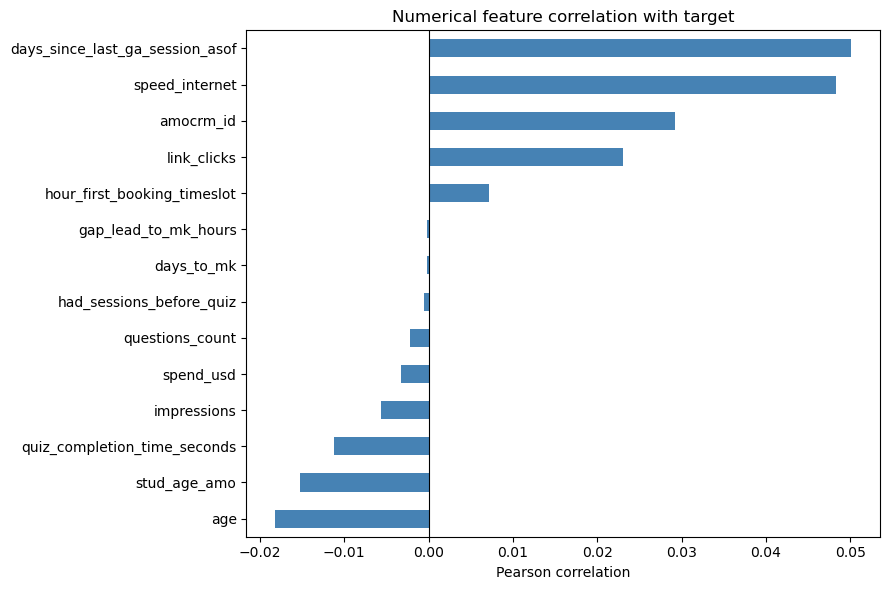

In [33]:
top_corr = numeric_corr.head(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top_corr.plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Numerical feature correlation with target")
ax.set_xlabel("Pearson correlation")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# 4. Data preprocessing

In [34]:
df = df.drop(columns = ['last_booking_status'])

## Time-based train-test split

In [35]:
def time_based_train_test_split(
    df: pd.DataFrame,
    time_col: str,
    target_col: str,
    train_size: float = 0.8,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """Chronological 80/20 split: earlier rows -> train, later rows -> test."""
    if time_col not in df.columns:
        raise KeyError(f"Time split column not found: {time_col}")
    if target_col not in df.columns:
        raise KeyError(f"Target column not found: {target_col}")
    if not 0 < train_size < 1:
        raise ValueError("train_size must be between 0 and 1")

    work = df.copy()
    work[time_col] = pd.to_datetime(work[time_col], errors="coerce")
    work = work.loc[work[time_col].notna()].copy()
    if work.empty:
        raise ValueError(f"No valid datetime values found in {time_col}")

    work = work.sort_values(time_col).reset_index(drop=True)

    split_idx = int(len(work) * train_size)
    df_train = work.iloc[:split_idx].copy()
    df_test = work.iloc[split_idx:].copy()

    X_train = df_train.drop(columns=[target_col]).copy()
    y_train = df_train[target_col].copy()
    X_test = df_test.drop(columns=[target_col]).copy()
    y_test = df_test[target_col].copy()

    return df_train, df_test, X_train, y_train, X_test, y_test


In [36]:
target_col = "visited_tc_7d_target"
split_time_col = "time_started"

df_train, df_test, X_train, y_train, X_test, y_test = time_based_train_test_split(
    df=df,
    time_col=split_time_col,
    target_col=target_col,
    train_size=0.8,
)


In [37]:
time_split_summary = pd.DataFrame({
    "rows": [len(df_train), len(df_test)],
    "share_pct": [len(df_train) / len(df) * 100, len(df_test) / len(df) * 100],
    "min_time": [df_train[split_time_col].min(), df_test[split_time_col].min()],
    "max_time": [df_train[split_time_col].max(), df_test[split_time_col].max()],
    "target_rate": [y_train.mean(), y_test.mean()],
}, index=["train", "test"])

time_split_summary


,rows,share_pct,min_time,max_time,target_rate
train,4552,80.00,2025-10-27 12:34:53.763,2026-02-11 17:45:07.266,0.23
test,1138,20.00,2026-02-11 18:22:46.885,2026-03-12 15:40:58.603,0.21


## Train-fitted rare category handling

In [38]:
def fit_rare_category_maps(
    df_train: pd.DataFrame,
    cols: Sequence[str],
    session_col: str = "session_id",
    default_min_sessions: int = 50,
    min_sessions_by_col: Optional[dict[str, int]] = None,
    unknown_values_by_col: Optional[dict[str, str]] = None,
) -> dict[str, dict[str, object]]:
    min_sessions_by_col = min_sessions_by_col or {}
    unknown_values_by_col = unknown_values_by_col or {}
    maps = {}

    for col in cols:
        if col not in df_train.columns:
            continue

        min_sessions = min_sessions_by_col.get(col, default_min_sessions)
        if session_col in df_train.columns:
            counts = df_train.groupby(col, dropna=False)[session_col].count()
        else:
            counts = df_train[col].value_counts(dropna=False)

        frequent_values = counts[counts >= min_sessions].index
        frequent_values = {value for value in frequent_values if pd.notna(value)}

        maps[col] = {
            "frequent_values": frequent_values,
            "unknown_value": unknown_values_by_col.get(col, "Unknown"),
        }

    return maps


def apply_rare_category_maps(
    df: pd.DataFrame,
    rare_category_maps: dict[str, dict[str, object]],
) -> pd.DataFrame:
    out = df.copy()

    for col, mapping in rare_category_maps.items():
        if col not in out.columns:
            continue

        frequent_values = mapping["frequent_values"]
        unknown_value = mapping["unknown_value"]
        known_mask = out[col].isin(frequent_values) | out[col].isna()

        if isinstance(out[col].dtype, pd.CategoricalDtype):
            if unknown_value not in out[col].cat.categories:
                out[col] = out[col].cat.add_categories([unknown_value])

        out.loc[~known_mask, col] = unknown_value

    return out


In [39]:
rare_category_cols = [
    "source",
    "course_global",
    "campaign_offer_empiric",
    "campaign_event_empiric",
    "utm_source",
    "utm_medium",
    "utm_content",
    "country",
]

rare_category_maps = fit_rare_category_maps(
    df_train=df_train,
    cols=rare_category_cols,
    default_min_sessions=50,
    min_sessions_by_col={"country": 100},
    unknown_values_by_col={"country": "unknown"},
)

df_train = apply_rare_category_maps(df_train, rare_category_maps)
df_test = apply_rare_category_maps(df_test, rare_category_maps)


## Train-fitted categorical missing values

In [40]:
def _resolve_cat_cols(
    df: pd.DataFrame,
    cols: Optional[Sequence[str]] = None,
) -> list[str]:
    if cols is None:
        return df.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    return [c for c in cols if c in df.columns]


def fit_categorical_missing_treatment(
    df_train: pd.DataFrame,
    cols: Optional[Sequence[str]] = None,
    exclude_cols: Optional[Sequence[str]] = None,
    session_col: str = "session_id",
    min_sessions: int = 50,
    unknown_value: str = "Unknown",
    flag_suffix: str = "_missing_flag",
    treat_empty_as_missing: bool = True,
) -> dict[str, object]:
    target_cols = _resolve_cat_cols(df_train, cols)
    exclude_cols = set(exclude_cols or [])
    target_cols = [col for col in target_cols if col not in exclude_cols]
    frequent_values_by_col = {}

    for col in target_cols:
        s = df_train[col]
        missing_mask = s.isna()

        if treat_empty_as_missing:
            empty_mask = s.astype("string").str.strip().eq("").fillna(False)
            missing_mask = missing_mask | empty_mask

        s_clean = s.mask(missing_mask, np.nan)

        if session_col in df_train.columns:
            counts = df_train.groupby(s_clean, dropna=False)[session_col].count()
        else:
            counts = s_clean.value_counts(dropna=False)

        frequent_values = counts[counts >= min_sessions].index
        frequent_values_by_col[col] = {value for value in frequent_values if pd.notna(value)}

    return {
        "target_cols": target_cols,
        "frequent_values_by_col": frequent_values_by_col,
        "unknown_value": unknown_value,
        "flag_suffix": flag_suffix,
        "treat_empty_as_missing": treat_empty_as_missing,
    }


def apply_categorical_missing_treatment(
    df: pd.DataFrame,
    treatment: dict[str, object],
) -> pd.DataFrame:
    out = df.copy()
    unknown_value = treatment["unknown_value"]
    flag_suffix = treatment["flag_suffix"]
    treat_empty_as_missing = treatment["treat_empty_as_missing"]
    frequent_values_by_col = treatment["frequent_values_by_col"]

    for col in treatment["target_cols"]:
        if col not in out.columns:
            continue

        s = out[col]
        missing_mask = s.isna()

        if treat_empty_as_missing:
            empty_mask = s.astype("string").str.strip().eq("").fillna(False)
            missing_mask = missing_mask | empty_mask

        frequent_values = frequent_values_by_col.get(col, set())
        frequent_mask = s.isin(frequent_values)
        replace_mask = missing_mask | (~missing_mask & ~frequent_mask)

        out[f"{col}{flag_suffix}"] = missing_mask.astype("int8")

        if isinstance(out[col].dtype, pd.CategoricalDtype):
            if unknown_value not in out[col].cat.categories:
                out[col] = out[col].cat.add_categories([unknown_value])

        out.loc[replace_mask, col] = unknown_value

    return out


In [41]:
datetime_cols = [col for col in date_cols if col in df_train.columns]

categorical_missing_treatment = fit_categorical_missing_treatment(
    df_train=df_train,
    exclude_cols=datetime_cols,
)

df_train = apply_categorical_missing_treatment(df_train, categorical_missing_treatment)
df_test = apply_categorical_missing_treatment(df_test, categorical_missing_treatment)

df = pd.concat([df_train, df_test], ignore_index=True)
X_train = df_train.drop(columns=[target_col]).copy()
y_train = df_train[target_col].copy()
X_test = df_test.drop(columns=[target_col]).copy()
y_test = df_test[target_col].copy()


# Drop datetime fields

In [42]:
def drop_datetime_columns(df: pd.DataFrame) -> pd.DataFrame:
    dt_cols = [
        c for c in df.columns
        if is_datetime64_any_dtype(df[c]) or isinstance(df[c].dtype, pd.DatetimeTZDtype)
    ]
    return df.drop(columns=dt_cols)


In [43]:
df = drop_datetime_columns(df)
df_train = drop_datetime_columns(df_train)
df_test = drop_datetime_columns(df_test)
X_train = drop_datetime_columns(X_train)
X_test = drop_datetime_columns(X_test)


## Drop technical identifier columns

In [44]:
technical_id_cols = ["amocrm_id"]

df = df.drop(columns=technical_id_cols, errors="ignore")
df_train = df_train.drop(columns=technical_id_cols, errors="ignore")
df_test = df_test.drop(columns=technical_id_cols, errors="ignore")
X_train = X_train.drop(columns=technical_id_cols, errors="ignore")
X_test = X_test.drop(columns=technical_id_cols, errors="ignore")


In [45]:
df.head()

,speed_internet,had_sessions_before_quiz,days_since_last_ga_session_asof,quiz_completion_time_seconds,questions_count,os_device,device_type,brand_device,country,source,utm_marketing,stud_age_amo,marketing_course_global,device_type_ui,utm_referrer,monthly_budget,extracurricular_spend,respondent,took_online_classes_before,reaction_to_trial_class,age,gender,decision_responsibility,free_time,internet_stability,would_pay_if_useful,has_computer,utm_content,utm_campaign,utm_medium,utm_source,impressions,link_clicks,spend_usd,region,campaign_event_empiric,ad_back_empiric,ad_group_product,ad_hero_dynamic_empiric,ad_product_empiric,creative_call_to_action_type,campaign_offer_empiric,campaign_bid_strategy_empiric,course_global,format,creative_concept,landing_id,product_offer_empiric,creative_uvp,visited_tc_7d_target,hour_first_booking_timeslot,gap_lead_to_mk_hours,days_to_mk,day_of_week_tc,day_of_week_quiz_start,os_device_missing_flag,device_type_missing_flag,brand_device_missing_flag,country_missing_flag,source_missing_flag,utm_marketing_missing_flag,marketing_course_global_missing_flag,device_type_ui_missing_flag,utm_referrer_missing_flag,monthly_budget_missing_flag,extracurricular_spend_missing_flag,respondent_missing_flag,took_online_classes_before_missing_flag,reaction_to_trial_class_missing_flag,gender_missing_flag,decision_responsibility_missing_flag,free_time_missing_flag,internet_stability_missing_flag,would_pay_if_useful_missing_flag,has_computer_missing_flag,utm_content_missing_flag,utm_campaign_missing_flag,utm_medium_missing_flag,utm_source_missing_flag,region_missing_flag,campaign_event_empiric_missing_flag,ad_back_empiric_missing_flag,ad_group_product_missing_flag,ad_hero_dynamic_empiric_missing_flag,ad_product_empiric_missing_flag,creative_call_to_action_type_missing_flag,campaign_offer_empiric_missing_flag,campaign_bid_strategy_empiric_missing_flag,course_global_missing_flag,format_missing_flag,creative_concept_missing_flag,landing_id_missing_flag,product_offer_empiric_missing_flag,creative_uvp_missing_flag,day_of_week_tc_missing_flag,day_of_week_quiz_start_missing_flag
0,8.68,1.00,12.00,8.10,4,Mac OS 10_15_7,Apple,Apple,unknown,Unknown,Unknown,7,Unknown,Apple,Unknown,Unknown,Unknown,padre / madre / tutor,Unknown,Unknown,NaN,niño,Unknown,con pantallas o dispositivos,Unknown,Unknown,"sí, computadora o laptop",Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,0,21,657,27,Sunday,Monday,0,0,0,0,0,1,1,0,0,1,1,0,1,1,0,1,0,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0
1,8.26,1.00,12.00,8.10,4,Mac OS 10_15_7,Apple,Apple,unknown,Unknown,Unknown,17,Unknown,Apple,Unknown,Unknown,Unknown,padre / madre / tutor,Unknown,Unknown,NaN,niño,Unknown,con pantallas o dispositivos,Unknown,Unknown,"sí, computadora o laptop",Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,0,19,847,35,Monday,Monday,0,0,0,0,0,1,1,0,0,1,1,0,1,1,0,1,0,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0
2,NaN,0.00,NaN,17.48,12,Mac OS 10_15_7,Apple,Apple,unknown,Unknown,Unknown,7,Unknown,Apple,Unknown,hasta 30 usd,no gastábamos nada,padre / madre / tutor,"sí, de forma regular",muestra interés en la programación,NaN,niño,yo tomo la decisión,con pantallas o dispositivos,es estable,"sí, lo estamos contemplando","sí, computadora o laptop",Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,0,2,230,10,Thursday,Monday,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0
3,NaN,0.00,NaN,18.59,12,Mac OS 10_15_7,Apple,Apple,unknown,Unknown,Unknown,11,Unknown,Apple,Unknown,30–60 usd,20–50 usd,padre / madre / tutor,"sí, solo una vez o por poco tiempo","no le interesa, pero podría aceptar probar",NaN,niña,lo decidimos 

# 5. Modelling

## 5.1 Historical attendance rate 

In [46]:
historical_ar = 0.07
historical_ar_latam = 0.08

# 5.2 Logistic Regression

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


cat_features_lr = X_train.select_dtypes(
    include=["object", "category", "string", "bool"]
).columns.tolist()
num_features_lr = [col for col in X_train.columns if col not in cat_features_lr]

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=True)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot_encoder),
])

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features_lr),
        ("cat", categorical_transformer, cat_features_lr),
    ]
)

logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42,
    )),
])

logreg_model.fit(X_train, y_train)

logreg_pred = logreg_model.predict(X_test)
logreg_proba = logreg_model.predict_proba(X_test)[:, 1]

In [48]:
logreg_metrics = {
    "model": "Logistic Regression",
    "accuracy": round(accuracy_score(y_test, logreg_pred), 2),
    "precision": round(precision_score(
        y_test,
        logreg_pred,
        average="weighted",
        zero_division=0,
    ), 2),
    "recall": round(recall_score(
        y_test,
        logreg_pred,
        average="weighted",
        zero_division=0,
    ), 2),
    "f1": round(f1_score(y_test, logreg_pred, average="weighted"), 2),
    "roc_auc": round(roc_auc_score(y_test, logreg_proba), 2),
}

metrics_df = add_model_metrics(metrics_df, logreg_metrics)

display(metrics_df.round(2))
print(classification_report(y_test, logreg_pred, zero_division=0))
print(confusion_matrix(y_test, logreg_pred))

/var/folders/78/8b3g8thx1b99pgrq0245szkr0000gn/T/ipykernel_85376/2417477244.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([metrics_df, metrics_row], ignore_index=True)


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.59,0.76,0.59,0.62,0.70


              precision    recall  f1-score   support

           0       0.88      0.54      0.67       894
           1       0.31      0.74      0.43       244

    accuracy                           0.59      1138
   macro avg       0.60      0.64      0.55      1138
weighted avg       0.76      0.59      0.62      1138

[[487 407]
 [ 64 180]]


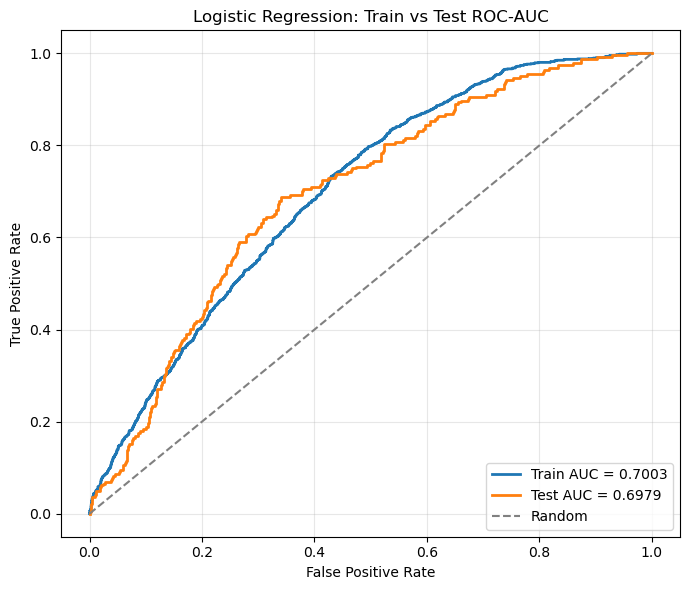

{'train_auc': 0.7002946558279731, 'test_auc': 0.6978948912604981}


In [49]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


def plot_train_test_roc_auc(model, X_train, y_train, X_test, y_test, title="Train vs Test ROC-AUC"):
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_proba)
    test_auc = roc_auc_score(y_test, test_proba)

    fpr_train, tpr_train, _ = roc_curve(y_train, train_proba)
    fpr_test, tpr_test, _ = roc_curve(y_test, test_proba)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr_train, tpr_train, label=f"Train AUC = {train_auc:.4f}", linewidth=2)
    plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.4f}", linewidth=2)
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Random")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "train_auc": train_auc,
        "test_auc": test_auc,
    }


logreg_aucs = plot_train_test_roc_auc(
    logreg_model,
    X_train,
    y_train,
    X_test,
    y_test,
    title="Logistic Regression: Train vs Test ROC-AUC",
)

print(logreg_aucs)

,feature,coefficient,abs_coefficient
0,campaign_bid_strategy_empiric_Unknown,1.19,1.19
1,landing_id_LatQuScoG2,0.78,0.78
2,utm_campaign_23527299808,0.78,0.78
3,ad_product_empiric_Roblox,-0.73,0.73
4,landing_id_Unknown,-0.68,0.68
5,country_Chile,0.66,0.66
6,os_device_iPhone OS 18_7,-0.63,0.63
7,utm_marketing_23303683895,0.63,0.63
8,product_offer_empiric_scoring_quiz,0.60,0.60
9,country_unknown,-0.56,0.56


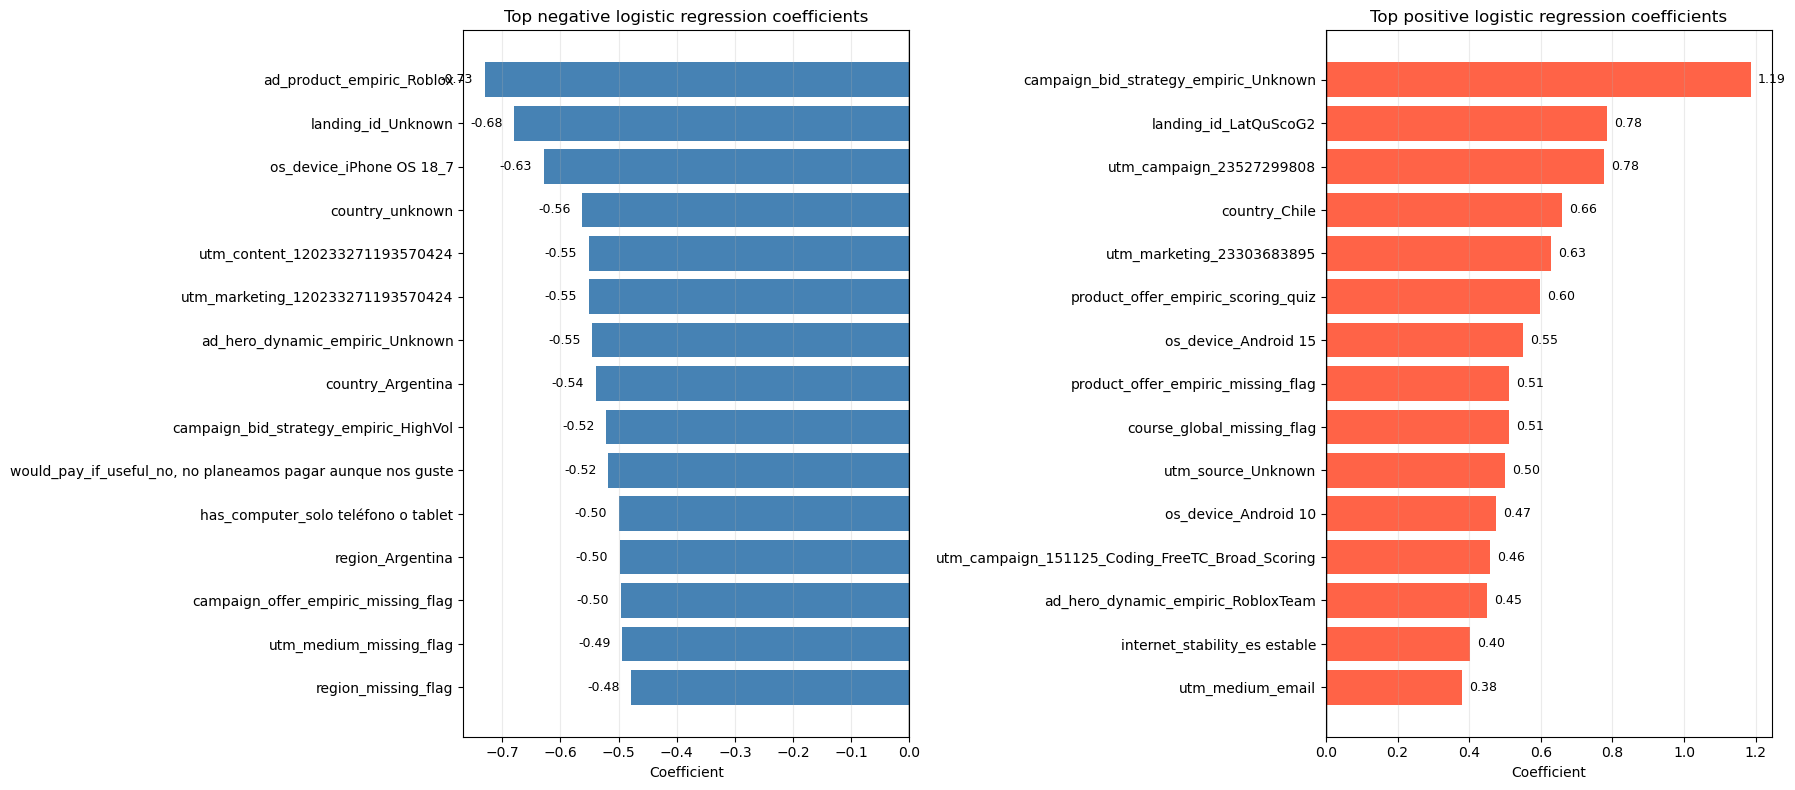

In [50]:
preprocessor = logreg_model.named_steps["preprocessor"]
classifier = logreg_model.named_steps["classifier"]

feature_names_lr = []

if num_features_lr:
    feature_names_lr.extend(num_features_lr)

if cat_features_lr:
    cat_pipeline = preprocessor.named_transformers_["cat"]
    onehot = cat_pipeline.named_steps["onehot"]

    try:
        cat_feature_names_lr = onehot.get_feature_names_out(cat_features_lr).tolist()
    except AttributeError:
        cat_feature_names_lr = onehot.get_feature_names(cat_features_lr).tolist()

    feature_names_lr.extend(cat_feature_names_lr)

logreg_coefficients = pd.DataFrame({
    "feature": feature_names_lr,
    "coefficient": classifier.coef_[0],
})

logreg_coefficients["abs_coefficient"] = logreg_coefficients["coefficient"].abs()
logreg_coefficients = logreg_coefficients.sort_values(
    "abs_coefficient",
    ascending=False,
).reset_index(drop=True)

display(logreg_coefficients.head(30).round(3))

top_positive_coefficients = (
    logreg_coefficients
    .sort_values("coefficient", ascending=False)
    .head(15)
)

top_negative_coefficients = (
    logreg_coefficients
    .sort_values("coefficient", ascending=True)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=False)

axes[0].barh(
    top_negative_coefficients["feature"],
    top_negative_coefficients["coefficient"],
    color="steelblue",
)
axes[0].set_title("Top negative logistic regression coefficients")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].invert_yaxis()

axes[1].barh(
    top_positive_coefficients["feature"],
    top_positive_coefficients["coefficient"],
    color="tomato",
)
axes[1].set_title("Top positive logistic regression coefficients")
axes[1].set_xlabel("Coefficient")
axes[1].set_ylabel("")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].invert_yaxis()

for ax in axes:
    ax.grid(axis="x", alpha=0.25)
    for patch in ax.patches:
        width = patch.get_width()
        x_offset = 0.02 if width >= 0 else -0.02
        ha = "left" if width >= 0 else "right"
        ax.text(
            width + x_offset,
            patch.get_y() + patch.get_height() / 2,
            f"{width:.2f}",
            va="center",
            ha=ha,
            fontsize=9,
        )

plt.tight_layout()
plt.show()


In [51]:
metrics_df.round(2)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.59,0.76,0.59,0.62,0.70


# 5.3 Decision Tree

In [52]:
from sklearn.tree import DecisionTreeClassifier


cat_features_dt = X_train.select_dtypes(
    include=["object", "category", "string", "bool"]
).columns.tolist()
num_features_dt = [col for col in X_train.columns if col not in cat_features_dt]

try:
    one_hot_encoder_dt = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    one_hot_encoder_dt = OneHotEncoder(handle_unknown="ignore", sparse=True)

numeric_transformer_dt = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer_dt = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot_encoder_dt),
])

preprocessor_dt = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_dt, num_features_dt),
        ("cat", categorical_transformer_dt, cat_features_dt),
    ]
)

dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor_dt),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
    )),
])

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

In [53]:
dt_metrics = {
    "model": "Decision Tree",
    "accuracy": round(accuracy_score(y_test, dt_pred), 2),
    "precision": round(precision_score(
        y_test,
        dt_pred,
        average="weighted",
        zero_division=0,
    ), 2),
    "recall": round(recall_score(
        y_test,
        dt_pred,
        average="weighted",
        zero_division=0,
    ), 2),
    "f1": round(f1_score(y_test, dt_pred, average="weighted"), 2),
    "roc_auc": round(roc_auc_score(y_test, dt_proba), 2),
}

metrics_df = add_model_metrics(metrics_df, dt_metrics)

display(metrics_df.round(2))
print(classification_report(y_test, dt_pred, zero_division=0))
print(confusion_matrix(y_test, dt_pred))

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.59,0.76,0.59,0.62,0.70
1,Decision Tree,0.50,0.76,0.50,0.53,0.63


              precision    recall  f1-score   support

           0       0.89      0.42      0.57       894
           1       0.27      0.81      0.41       244

    accuracy                           0.50      1138
   macro avg       0.58      0.61      0.49      1138
weighted avg       0.76      0.50      0.53      1138

[[373 521]
 [ 47 197]]


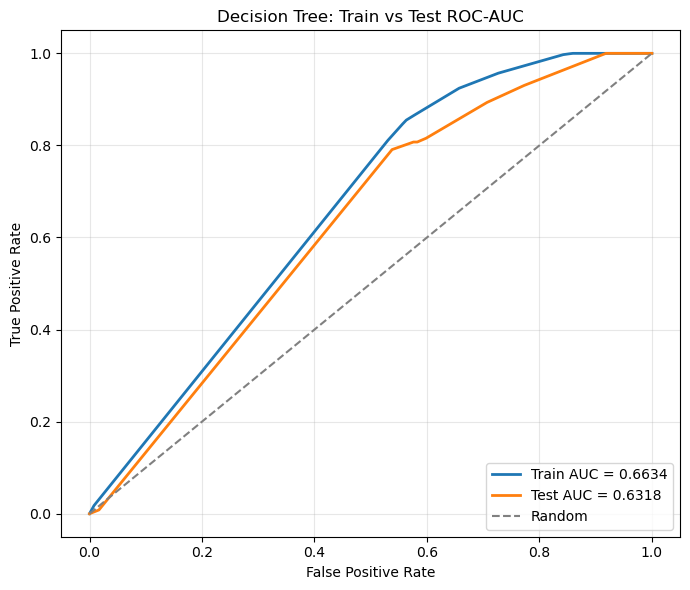

{'train_auc': 0.6634133934516092, 'test_auc': 0.6317755895404701}


In [54]:
dt_aucs = plot_train_test_roc_auc(
    dt_model,
    X_train,
    y_train,
    X_test,
    y_test,
    title="Decision Tree: Train vs Test ROC-AUC",
)

print(dt_aucs)

,feature,importance
0,gap_lead_to_mk_hours,0.47
1,has_computer,0.24
2,country,0.11
3,internet_stability,0.06
4,device_type,0.05
5,would_pay_if_useful,0.04
6,spend_usd,0.02
7,speed_internet,0.01
8,ad_back_empiric,0.00
9,quiz_completion_time_seconds,0.00


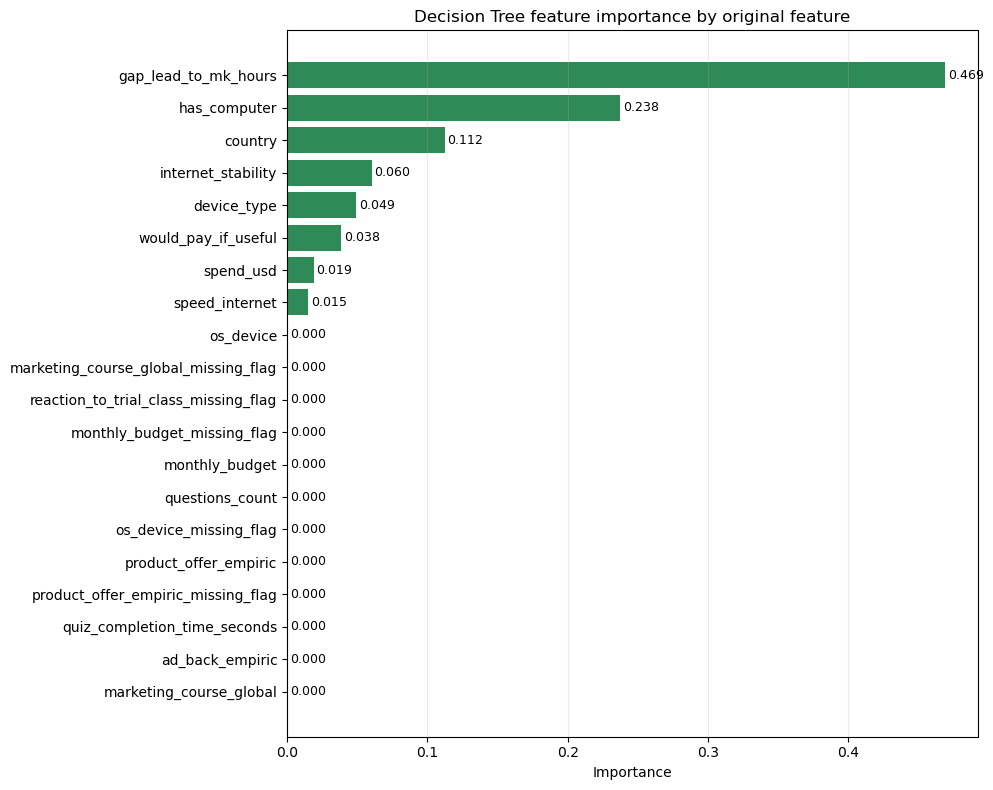

In [55]:
preprocessor = dt_model.named_steps["preprocessor"]
classifier = dt_model.named_steps["classifier"]

feature_importance_rows_dt = []
importance_offset_dt = 0

if num_features_dt:
    for feature, importance in zip(
        num_features_dt,
        classifier.feature_importances_[:len(num_features_dt)],
    ):
        feature_importance_rows_dt.append({
            "feature": feature,
            "importance": importance,
        })

    importance_offset_dt = len(num_features_dt)

if cat_features_dt:
    cat_pipeline = preprocessor.named_transformers_["cat"]
    onehot = cat_pipeline.named_steps["onehot"]
    cat_importances_dt = classifier.feature_importances_[importance_offset_dt:]

    for feature, categories in zip(cat_features_dt, onehot.categories_):
        n_categories = len(categories)
        feature_importance_rows_dt.append({
            "feature": feature,
            "importance": cat_importances_dt[:n_categories].sum(),
        })
        cat_importances_dt = cat_importances_dt[n_categories:]

dt_feature_importance = (
    pd.DataFrame(feature_importance_rows_dt)
    .groupby("feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(dt_feature_importance.head(30).round(3))

top_dt_features = dt_feature_importance.head(20).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    top_dt_features["feature"],
    top_dt_features["importance"],
    color="seagreen",
)
ax.set_title("Decision Tree feature importance by original feature")
ax.set_xlabel("Importance")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
ax.invert_yaxis()

for patch in ax.patches:
    width = patch.get_width()
    ax.text(
        width + 0.002,
        patch.get_y() + patch.get_height() / 2,
        f"{width:.3f}",
        va="center",
        ha="left",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


# 5.4 Random Forest

In [56]:
from sklearn.ensemble import RandomForestClassifier


cat_features_rf = X_train.select_dtypes(
    include=["object", "category", "string", "bool"]
).columns.tolist()
num_features_rf = [col for col in X_train.columns if col not in cat_features_rf]

try:
    one_hot_encoder_rf = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    one_hot_encoder_rf = OneHotEncoder(handle_unknown="ignore", sparse=True)

numeric_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot_encoder_rf),
])

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_rf, num_features_rf),
        ("cat", categorical_transformer_rf, cat_features_rf),
    ]
)

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42,
    )),
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]


In [57]:
rf_metrics = {
    "model": "Random Forest",
    "accuracy": round(accuracy_score(y_test, rf_pred), 2),
    "precision": round(precision_score(
        y_test,
        rf_pred,
        average="weighted",
        zero_division=0,
    ), 2),
    "recall": round(recall_score(
        y_test,
        rf_pred,
        average="weighted",
        zero_division=0,
    ), 2),
    "f1": round(f1_score(y_test, rf_pred, average="weighted"), 2),
    "roc_auc": round(roc_auc_score(y_test, rf_proba), 2),
}

metrics_df = add_model_metrics(metrics_df, rf_metrics)

display(metrics_df.round(2))
print(classification_report(y_test, rf_pred, zero_division=0))
print(confusion_matrix(y_test, rf_pred))


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.59,0.76,0.59,0.62,0.70
1,Decision Tree,0.50,0.76,0.50,0.53,0.63
2,Random Forest,0.58,0.76,0.58,0.61,0.70


              precision    recall  f1-score   support

           0       0.88      0.53      0.66       894
           1       0.30      0.74      0.43       244

    accuracy                           0.58      1138
   macro avg       0.59      0.64      0.55      1138
weighted avg       0.76      0.58      0.61      1138

[[475 419]
 [ 63 181]]


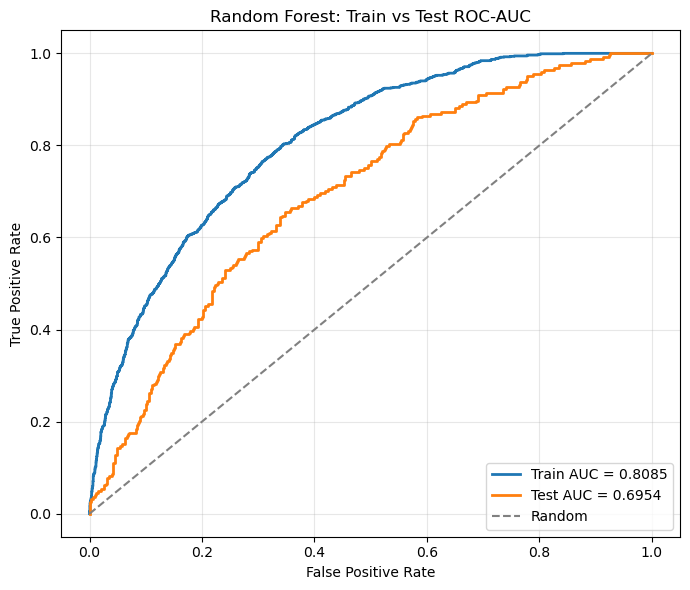

{'train_auc': 0.8085228614086273, 'test_auc': 0.6953506069607951}


In [58]:
rf_aucs = plot_train_test_roc_auc(
    rf_model,
    X_train,
    y_train,
    X_test,
    y_test,
    title="Random Forest: Train vs Test ROC-AUC",
)

print(rf_aucs)


,feature,importance
0,gap_lead_to_mk_hours,0.12
1,has_computer,0.12
2,days_to_mk,0.09
3,country,0.06
4,speed_internet,0.04
5,internet_stability,0.04
6,quiz_completion_time_seconds,0.04
7,would_pay_if_useful,0.03
8,spend_usd,0.03
9,link_clicks,0.03


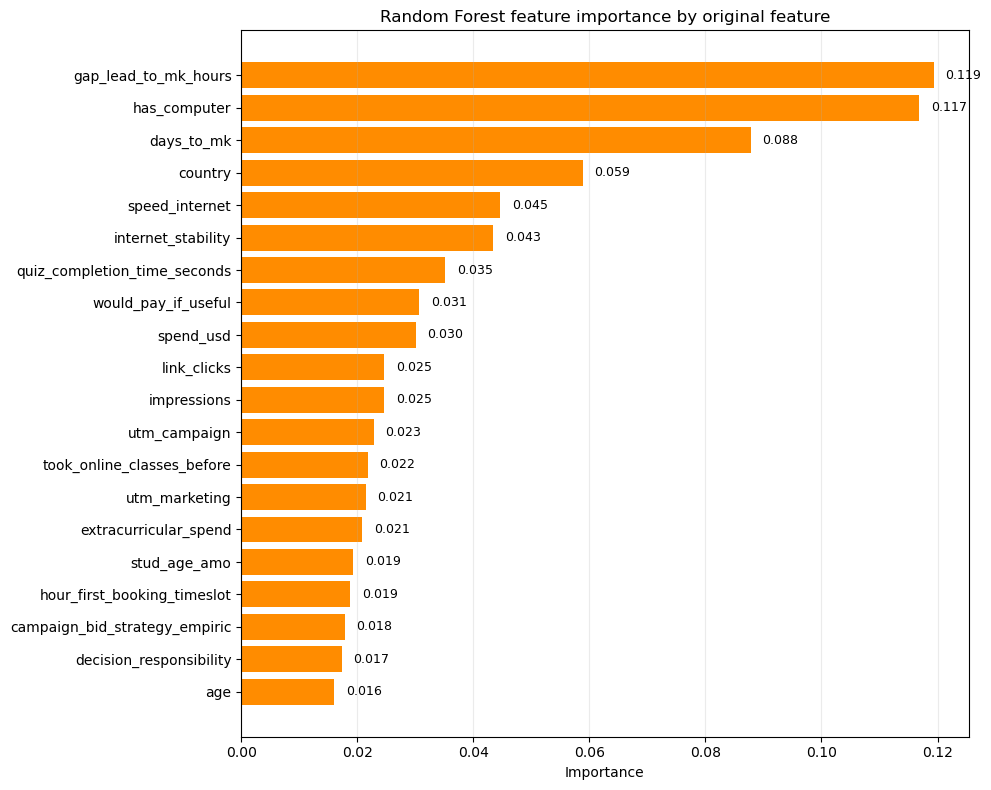

In [59]:
preprocessor = rf_model.named_steps["preprocessor"]
classifier = rf_model.named_steps["classifier"]

feature_importance_rows_rf = []
importance_offset_rf = 0

if num_features_rf:
    for feature, importance in zip(
        num_features_rf,
        classifier.feature_importances_[:len(num_features_rf)],
    ):
        feature_importance_rows_rf.append({
            "feature": feature,
            "importance": importance,
        })

    importance_offset_rf = len(num_features_rf)

if cat_features_rf:
    cat_pipeline = preprocessor.named_transformers_["cat"]
    onehot = cat_pipeline.named_steps["onehot"]
    cat_importances_rf = classifier.feature_importances_[importance_offset_rf:]

    for feature, categories in zip(cat_features_rf, onehot.categories_):
        n_categories = len(categories)
        feature_importance_rows_rf.append({
            "feature": feature,
            "importance": cat_importances_rf[:n_categories].sum(),
        })
        cat_importances_rf = cat_importances_rf[n_categories:]

rf_feature_importance = (
    pd.DataFrame(feature_importance_rows_rf)
    .groupby("feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(rf_feature_importance.head(30).round(3))

top_rf_features = rf_feature_importance.head(20).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    top_rf_features["feature"],
    top_rf_features["importance"],
    color="darkorange",
)
ax.set_title("Random Forest feature importance by original feature")
ax.set_xlabel("Importance")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
ax.invert_yaxis()

for patch in ax.patches:
    width = patch.get_width()
    ax.text(
        width + 0.002,
        patch.get_y() + patch.get_height() / 2,
        f"{width:.3f}",
        va="center",
        ha="left",
        fontsize=9,
    )

plt.tight_layout()
plt.show()
